# Node Conviction: correlation with degree and betweenness across checkpoints

For each training checkpoint we load the saved node norms (conviction), then compute
Spearman ρ between conviction and (i) node degree and (ii) betweenness centrality,
for every diffusion-layer snapshot X_0 … X_L.  
The result is a 2-panel figure where each curve is one checkpoint and the x-axis is the layer.

## 1. Imports

In [5]:
import os
import glob
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import spearmanr

## 2. Config

In [6]:
dataset          = "citeseer"
model            = "GeneralSheaf"
Norm             = "true"          # must match --normalised flag (true / false)
stalk_dim        = 5
layers           = 4
hidden_channels  = 16
epochs           = 500
seed             = 43
num_folds        = 10
learn_first_maps = False
learnt_map_type  = "general"        # only relevant for JointSheafParams* models

checkpoint_names = ['epoch-0', 'epoch-1', 'epoch-5', 'epoch-15', 'epoch-50', 'epoch-200', 'best-epoch', 'last']

# ---- map tag: mirrors _map_tag() in run.py ---------------------------------
_JOINT_MODELS = {'JointSheafParams', 'JointSheafParamsAlt'}
_TYPE_SHORT   = {'diagonal': 'diag', 'bundle': 'bundle', 'general': 'general'}

if model in _JOINT_MODELS:
    if not learn_first_maps:
        map_tag = "_first_maps_identity"
    else:
        short   = _TYPE_SHORT.get(learnt_map_type, learnt_map_type)
        map_tag = f"_first_maps_{short}"
else:
    map_tag = ""

# ---- derived base dirs -----------------------------------------------------
BASE_NORMS = (
    f"../results/node_norms/{dataset}/{model}{map_tag}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
    f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs"
)
BASE_CONF = (
    f"../results/node_conf/{dataset}/{model}{map_tag}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
    f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs"
)
BASE_SAL = (
    f"../results/node_saliency/{dataset}/{model}{map_tag}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
    f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs"
)
BASE_ACC = (
    f"../results/node_accuracy/{dataset}/{model}{map_tag}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
    f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs"
)
BASE_PREDS = (
    f"../results/node_preds/{dataset}/{model}{map_tag}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
    f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs"
)

def _ckpt_filename(fold):
    return f"{model}_{dataset}{map_tag}_fold{fold}_seed{seed}.pt"

def norm_path(fold, ckpt_name):
    fn = _ckpt_filename(fold)
    return os.path.join(BASE_NORMS, fn) if ckpt_name == 'last' \
        else os.path.join(BASE_NORMS, 'checkpoints', ckpt_name, fn)

def conf_path(fold, ckpt_name):
    fn = _ckpt_filename(fold)
    return os.path.join(BASE_CONF, fn) if ckpt_name == 'last' \
        else os.path.join(BASE_CONF, 'checkpoints', ckpt_name, fn)

def sal_path(fold, ckpt_name):
    fn = _ckpt_filename(fold)
    return os.path.join(BASE_SAL, fn) if ckpt_name == 'last' \
        else os.path.join(BASE_SAL, 'checkpoints', ckpt_name, fn)

def acc_path(fold, ckpt_name):
    fn = _ckpt_filename(fold)
    return os.path.join(BASE_ACC, fn) if ckpt_name == 'last' \
        else os.path.join(BASE_ACC, 'checkpoints', ckpt_name, fn)

def preds_path(fold):
    # always last-epoch — used only to load fixed train/test masks
    return os.path.join(BASE_PREDS, _ckpt_filename(fold))

num_snapshots   = layers + 1
snapshot_labels = [f"X_{t}" for t in range(num_snapshots)]

print(f"model dir  : {model}{map_tag}")
print(f"BASE_NORMS : {BASE_NORMS}")
print(f"Snapshots  : {num_snapshots}  ({snapshot_labels[0]} … {snapshot_labels[-1]})")

model dir  : GeneralSheaf
BASE_NORMS : ../results/node_norms/citeseer/GeneralSheaf/normalised-true/stalk_dim-5/4-layers/16-hidden/500-epochs
Snapshots  : 5  (X_0 … X_4)


## 3. Build graph — degree and betweenness centrality

The graph topology is fixed for the dataset regardless of model or normalisation.
We load the raw edge files directly — no PyG dependency needed.

In [7]:
import sys, re
sys.path.insert(0, "..")
from definitions import ROOT_DIR

data_root = os.path.join(ROOT_DIR, "datasets")

# ---- load edges depending on dataset family ------------------------------
_NPY_DATASETS = {"roman_empire", "minesweeper", "amazon_ratings", "tolokers", "questions"}
_WEBKB_DATASETS = {"cornell", "texas", "wisconsin"}

if dataset in _NPY_DATASETS:
    # shape (E, 2) — each row is [src, dst]
    raw_edges = np.load(os.path.join(data_root, dataset, "raw", "edges.npy"))
    src, dst  = raw_edges[:, 0].astype(int), raw_edges[:, 1].astype(int)
    n         = int(np.load(os.path.join(data_root, dataset, "raw", "node_features.npy")).shape[0])

elif dataset in _WEBKB_DATASETS:
    # tab-separated edge list
    edge_file = os.path.join(data_root, dataset, "raw", "out1_graph_edges.txt")
    raw_edges = np.loadtxt(edge_file, dtype=int, skiprows=1)
    src, dst  = raw_edges[:, 0], raw_edges[:, 1]
    feat_file = os.path.join(data_root, dataset, "raw", "out1_node_feature_label.txt")
    with open(feat_file) as _f:
        n = sum(1 for line in _f) - 1   # subtract header

else:
    # Planetoid datasets (cora, citeseer, pubmed) — load via PyG
    import torch
    from torch_geometric.datasets import Planetoid
    import torch_geometric.transforms as T
    _ds  = Planetoid(root=data_root, name=dataset, transform=T.NormalizeFeatures())
    _ei  = _ds[0].edge_index.numpy()
    src, dst = _ei[0], _ei[1]
    n = _ds[0].num_nodes

edges = set()
for u, v in zip(src, dst):
    if u != v:
        edges.add((min(int(u), int(v)), max(int(u), int(v))))

G        = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from(sorted(edges))
nodelist = list(range(n))
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

node_degrees = np.array([G.degree(u) for u in nodelist], dtype=float)
print(f"Degree — min: {node_degrees.min():.0f}, max: {node_degrees.max():.0f}, mean: {node_degrees.mean():.2f}")

# Betweenness: approximate for large graphs (k = number of pivot nodes)
k_approx         = min(500, n)
print(f"Computing betweenness centrality (k={k_approx} pivots) …")
betweenness      = nx.betweenness_centrality(G, k=k_approx, seed=42)
node_betweenness = np.array([betweenness[u] for u in nodelist], dtype=float)
print(f"Betweenness — min: {node_betweenness.min():.4f}, max: {node_betweenness.max():.4f}")

/home/fguadagn/miniconda3/envs/Do_nsd/lib/python3.9/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([GlobalStorage])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


Graph: 3327 nodes, 4552 edges
Degree — min: 0, max: 99, mean: 2.74
Computing betweenness centrality (k=500 pivots) …
Betweenness — min: 0.0000, max: 0.0719


## 4. Load norms and compute Spearman correlations

For every checkpoint and every fold, we load the norm dict `{snapshot: tensor(n)}`
and compute Spearman ρ(norm, degree) and Spearman ρ(norm, betweenness) at each snapshot.
Results are averaged (± std) across available folds.

In [8]:
def _cohens_d(conv_subset, correct_mask):
    """Cohen's d = (mean_correct - mean_wrong) / pooled within-group std."""
    c_ok   = conv_subset[correct_mask]
    c_fail = conv_subset[~correct_mask]
    n1, n2 = len(c_ok), len(c_fail)
    if n1 < 2 or n2 < 2:
        return float('nan')
    s_p = np.sqrt(((n1 - 1) * c_ok.std()**2 + (n2 - 1) * c_fail.std()**2) / (n1 + n2 - 2))
    return (c_ok.mean() - c_fail.mean()) / s_p if s_p > 0 else float('nan')


results = {}

for ckpt_name in checkpoint_names:
    print(f"\n--- {ckpt_name} ---")

    buf_deg     = []
    buf_bet     = []
    buf_conf    = []
    buf_sal     = []
    buf_d_train = []
    buf_d_test  = []

    for fold in range(num_folds):
        np_path = norm_path(fold, ckpt_name)
        cp_path = conf_path(fold, ckpt_name)
        sp_path = sal_path(fold, ckpt_name)
        ap_path = acc_path(fold, ckpt_name)
        pp_path = preds_path(fold)   # always last-epoch, only used for masks

        if not os.path.exists(np_path):
            print(f"  fold {fold} — norms missing, skipped")
            continue

        norms_dict = torch.load(np_path, weights_only=False)

        conf_vec = torch.load(cp_path, weights_only=False).numpy() \
                   if os.path.exists(cp_path) else None
        sal_vec  = torch.load(sp_path, weights_only=False).numpy() \
                   if os.path.exists(sp_path) else None
        acc_vec  = torch.load(ap_path, weights_only=False).numpy().astype(bool) \
                   if os.path.exists(ap_path) else None

        # Masks are fixed per fold (epoch-independent) — load from last-epoch preds
        if os.path.exists(pp_path) and acc_vec is not None:
            _p         = torch.load(pp_path, weights_only=False)
            train_mask = _p['train_mask'].numpy()
            test_mask  = _p['test_mask'].numpy()
        else:
            train_mask = test_mask = None

        rho_deg_row  = []
        rho_bet_row  = []
        rho_conf_row = []
        rho_sal_row  = []
        d_train_row  = []
        d_test_row   = []
        ok = True

        for t in range(num_snapshots):
            if t not in norms_dict:
                print(f"  fold {fold} — snapshot {t} missing, skipped")
                ok = False
                break
            norms_t = norms_dict[t].numpy()
            rho_deg_row.append(spearmanr(norms_t, node_degrees).statistic)
            rho_bet_row.append(spearmanr(norms_t, node_betweenness).statistic)
            rho_conf_row.append(spearmanr(norms_t, conf_vec).statistic
                                if conf_vec is not None else float('nan'))
            rho_sal_row.append(spearmanr(norms_t, sal_vec).statistic
                               if sal_vec  is not None else float('nan'))

            if acc_vec is not None and train_mask is not None:
                d_train_row.append(_cohens_d(norms_t[train_mask], acc_vec[train_mask]))
                d_test_row.append( _cohens_d(norms_t[test_mask],  acc_vec[test_mask]))
            else:
                d_train_row.append(float('nan'))
                d_test_row.append(float('nan'))

        if ok:
            buf_deg.append(rho_deg_row)
            buf_bet.append(rho_bet_row)
            buf_conf.append(rho_conf_row)
            buf_sal.append(rho_sal_row)
            buf_d_train.append(d_train_row)
            buf_d_test.append(d_test_row)
            print(f"  fold {fold} done")

    n_avail = len(buf_deg)
    if n_avail == 0:
        print(f"  No folds available — skipping.")
        continue

    buf_deg     = np.array(buf_deg)
    buf_bet     = np.array(buf_bet)
    buf_conf    = np.array(buf_conf)
    buf_sal     = np.array(buf_sal)
    buf_d_train = np.array(buf_d_train)
    buf_d_test  = np.array(buf_d_test)

    results[ckpt_name] = {
        'rho_deg_mean':  buf_deg.mean(axis=0),
        'rho_deg_std':   buf_deg.std(axis=0),
        'rho_bet_mean':  buf_bet.mean(axis=0),
        'rho_bet_std':   buf_bet.std(axis=0),
        'rho_conf_mean': np.nanmean(buf_conf,    axis=0),
        'rho_conf_std':  np.nanstd(buf_conf,     axis=0),
        'rho_sal_mean':  np.nanmean(buf_sal,     axis=0),
        'rho_sal_std':   np.nanstd(buf_sal,      axis=0),
        'd_train_mean':  np.nanmean(buf_d_train, axis=0),
        'd_train_std':   np.nanstd(buf_d_train,  axis=0),
        'd_test_mean':   np.nanmean(buf_d_test,  axis=0),
        'd_test_std':    np.nanstd(buf_d_test,   axis=0),
        'n_folds': n_avail,
    }
    print(f"  -> {n_avail} fold(s) | deg ρ@X_L={buf_deg[:,-1].mean():.3f}"
          f"  conf ρ@X_L={np.nanmean(buf_conf[:,-1]):.3f}"
          f"  d_train@X_L={np.nanmean(buf_d_train[:,-1]):.3f}"
          f"  d_test@X_L={np.nanmean(buf_d_test[:,-1]):.3f}")

print("\nDone. Checkpoints:", list(results.keys()))


--- epoch-0 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) | deg ρ@X_L=-0.021  conf ρ@X_L=0.016  d_train@X_L=-0.031  d_test@X_L=-0.020

--- epoch-1 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) | deg ρ@X_L=0.092  conf ρ@X_L=0.295  d_train@X_L=0.602  d_test@X_L=0.484

--- epoch-5 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) | deg ρ@X_L=0.116  conf ρ@X_L=0.700  d_train@X_L=1.251  d_test@X_L=1.020

--- epoch-15 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) | deg ρ@X_L=0.285  conf ρ@X_L=0.704  d_train@X_L=0.526  d_test@X_L=0.296

--- epoch-5

/tmp/ipykernel_3554009/1519151391.py:110: RuntimeWarning: Mean of empty slice
  'd_train_mean':  np.nanmean(buf_d_train, axis=0),
/home/fguadagn/miniconda3/envs/Do_nsd/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3554009/1519151391.py:118: RuntimeWarning: Mean of empty slice
  f"  d_train@X_L={np.nanmean(buf_d_train[:,-1]):.3f}"


## 5. Plot - Heatmap

Saved to conviction_plots/citeseer_GeneralSheaf_d5_4L_Norm_true_conviction_heatmap.pdf


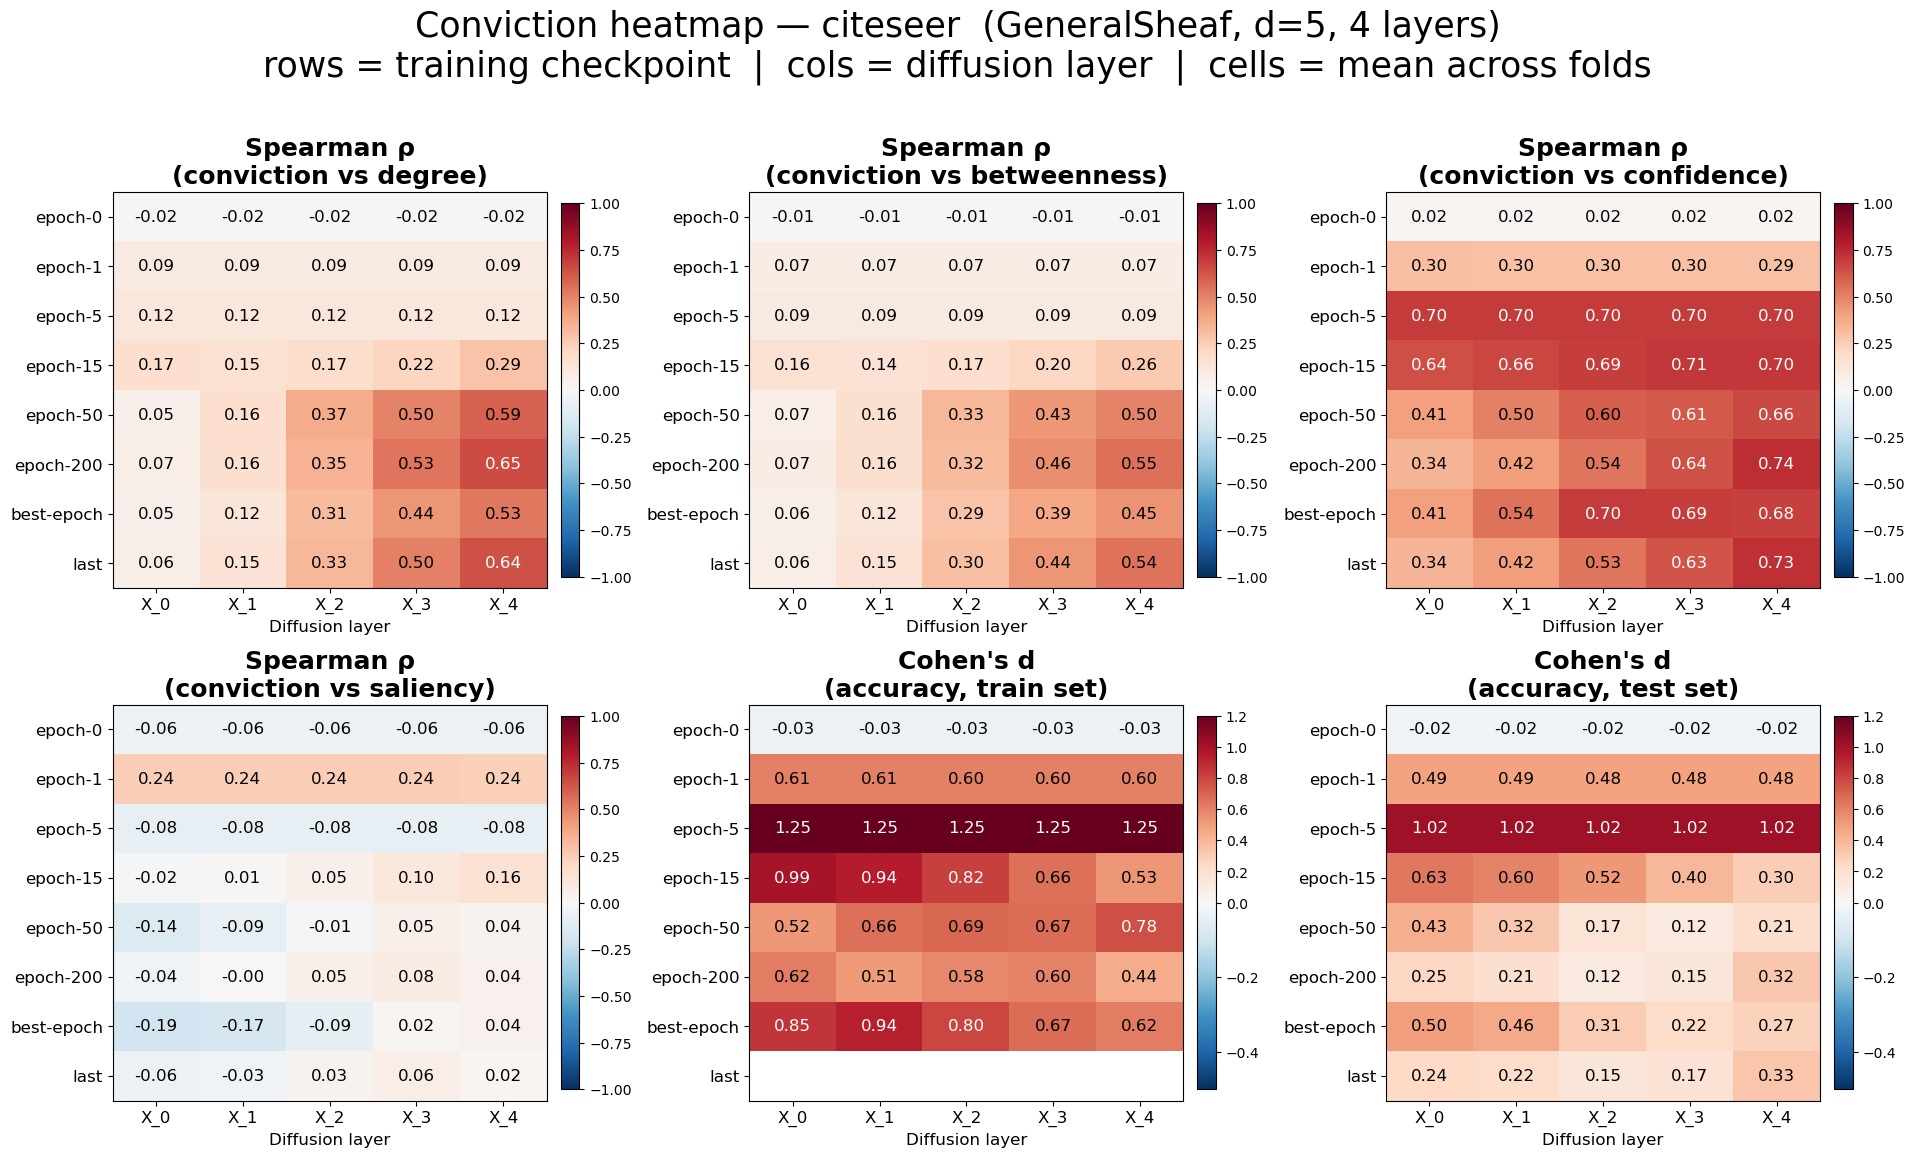

In [9]:
from matplotlib.colors import TwoSlopeNorm

# ── spec: (results_key, panel_title, cmap, vmin, vcenter, vmax) ──────────────
heatmap_specs = [
    ('rho_deg_mean',  'Spearman ρ\n(conviction vs degree)',      'RdBu_r', -1.0, 0,  1.0),
    ('rho_bet_mean',  'Spearman ρ\n(conviction vs betweenness)', 'RdBu_r', -1.0, 0,  1.0),
    ('rho_conf_mean', 'Spearman ρ\n(conviction vs confidence)',  'RdBu_r', -1.0, 0,  1.0),
    ('rho_sal_mean',  'Spearman ρ\n(conviction vs saliency)',    'RdBu_r', -1.0, 0,  1.0),
    ('d_train_mean',  "Cohen's d\n(accuracy, train set)",        'RdBu_r', -0.5, 0,  1.2),
    ('d_test_mean',   "Cohen's d\n(accuracy, test set)",         'RdBu_r', -0.5, 0,  1.2),
]

valid   = [c for c in checkpoint_names if c in results]
n_ckpts = len(valid)

# ── build matrices (n_ckpts × num_snapshots) ─────────────────────────────────
mats = {}
for key, *_ in heatmap_specs:
    mat = np.full((n_ckpts, num_snapshots), np.nan)
    for i, ckpt in enumerate(valid):
        mat[i] = results[ckpt][key]
    mats[key] = mat

# ── figure ────────────────────────────────────────────────────────────────────
cell_w  = 0.85
cell_h  = 0.55
panel_w = num_snapshots * cell_w   # width per heatmap panel
panel_h = n_ckpts       * cell_h   # height per heatmap panel
fig_w   = 3 * panel_w + 2 * 2.5 + 1.5   # 3 cols, gaps, margins
fig_h   = 2 * panel_h + 1.5 + 1.0       # 2 rows, gaps, margins

fig, axes = plt.subplots(2, 3, figsize=(fig_w, fig_h))

for ax, (key, title, cmap, vmin, vcenter, vmax) in zip(axes.flat, heatmap_specs):
    mat      = mats[key]
    norm_obj = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    im = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm_obj,
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)

    ax.set_title(title, fontsize=18, fontweight='bold', pad=6)
    ax.set_xlabel("Diffusion layer", fontsize=12)
    ax.set_xticks(range(num_snapshots))
    ax.set_xticklabels(snapshot_labels, fontsize=12)
    ax.set_yticks(range(n_ckpts))
    ax.set_yticklabels(valid, fontsize=12)

    # Annotate each cell with its value
    max_abs = max(abs(vmin), abs(vmax))
    for i in range(n_ckpts):
        for j in range(num_snapshots):
            val = mat[i, j]
            if not np.isnan(val):
                intensity  = abs(val) / max_abs
                text_color = 'white' if intensity > 0.6 else 'black'
                ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                        fontsize=12, color=text_color)

fig.suptitle(
    f"Conviction heatmap — {dataset}  ({model}{map_tag}, d={stalk_dim}, {layers} layers)\n"
    f"rows = training checkpoint  |  cols = diffusion layer  |  cells = mean across folds",
    fontsize=25, y=1.02
)
fig.tight_layout()

os.makedirs("metric_images", exist_ok=True)
out_path = (
    f"conviction_plots/{dataset}_{model}{map_tag}_d{stalk_dim}_{layers}L_"
    f"Norm_{Norm}_conviction_heatmap.pdf"
)
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved to {out_path}")
plt.show()


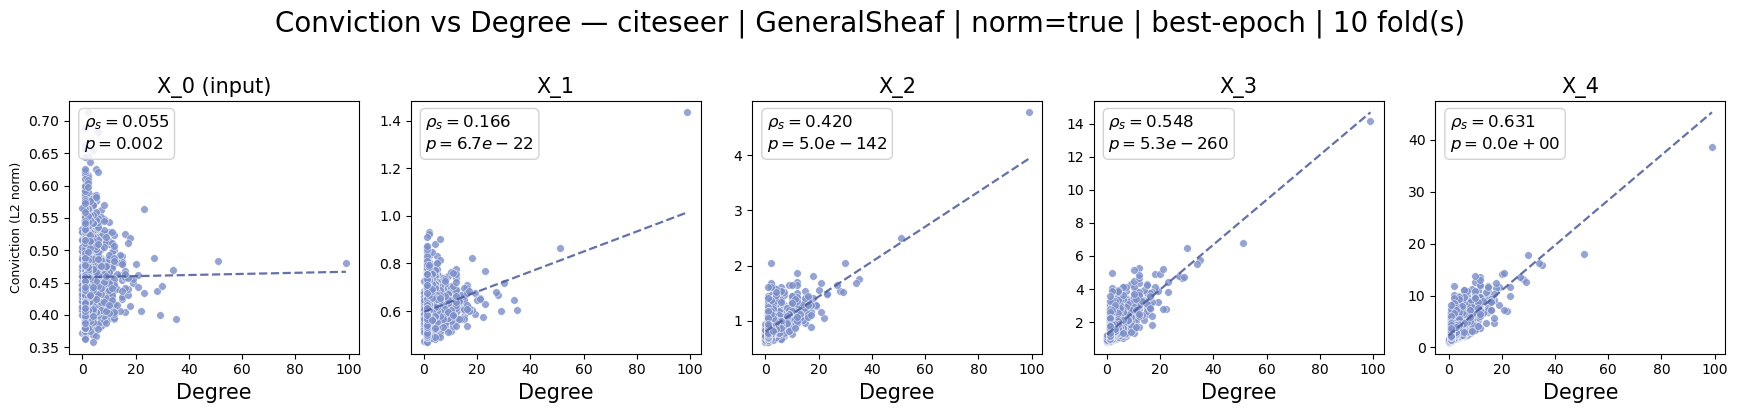

In [15]:
# ── Scatter: conviction vs degree at best-epoch, one subplot per layer ────────
from scipy.stats import spearmanr, linregress
import numpy as np

scatter_ckpt = 'best-epoch'   # change to any checkpoint_names entry
num_snapshots = layers + 1

# Average norms across folds for the chosen checkpoint
norms_avg = np.zeros((num_snapshots, n))  # n = number of nodes
fold_count = 0
for fold in range(num_folds):
    np_path = norm_path(fold, scatter_ckpt)
    if not os.path.exists(np_path):
        continue
    norms_dict = torch.load(np_path, weights_only=False)
    for t in range(num_snapshots):
        if t in norms_dict:
            norms_avg[t] += norms_dict[t].numpy()
    fold_count += 1

if fold_count == 0:
    print(f"No folds found for {scatter_ckpt}")
else:
    norms_avg /= fold_count

    deg = np.asarray(node_degrees, dtype=float)

    fig, axes = plt.subplots(
        1, num_snapshots,
        figsize=(3.5 * num_snapshots, 4.0),
        sharey=False,
    )
    if num_snapshots == 1:
        axes = [axes]

    SCATTER_C = "#7B8EC8"
    LINE_C    = "#4A5899"

    for t, ax in enumerate(axes):
        y = norms_avg[t]
        valid = np.isfinite(deg) & np.isfinite(y)
        xv, yv = deg[valid], y[valid]

        ax.scatter(xv, yv, color=SCATTER_C, alpha=0.8, s=30,
                   edgecolors="white", linewidths=0.4, rasterized=True)

        slope, intercept, r, *_ = linregress(xv, yv)
        xs = np.linspace(xv.min(), xv.max(), 200)
        ax.plot(xs, slope * xs + intercept, color=LINE_C,
                lw=1.6, ls="--", alpha=0.85)

        rho, pval = spearmanr(xv, yv)
        p_str = f"{pval:.1e}" if pval < 0.001 else f"{pval:.3f}"
        ax.text(0.05, 0.95,
                f"$\\rho_s = {rho:.3f}$\n$p = {p_str}$",
                transform=ax.transAxes, fontsize=12, va="top",
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          ec="#cccccc", alpha=0.85))

        label = "X_0 (input)" if t == 0 else f"X_{t}"
        ax.set_title(label, fontsize=15)
        ax.set_xlabel("Degree", fontsize=15)
        if t == 0:
            ax.set_ylabel("Conviction (L2 norm)", fontsize=9)

    fig.suptitle(
        f"Conviction vs Degree — {dataset} | {model} | norm={Norm} | {scatter_ckpt} | {fold_count} fold(s)",
        fontsize=20, y=1.02,
    )
    plt.tight_layout()
    plt.show()
